# Data Visualisation

##### Generates figures from the aggregated BehaviorSpace results.

In [28]:
# Dependencies
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

In [29]:
# Project directories
PROJECT_DIR = Path("..")

AGGREGATED_DIR = PROJECT_DIR / "data" / "aggregated"
FIGURES_DIR = PROJECT_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)


# Input files
FULL_SWEEP = AGGREGATED_DIR / "full_sweep_means.csv"
MODEL_VARIANTS = AGGREGATED_DIR / "model_variants_means.csv"
TIME_SERIES_HIGH = AGGREGATED_DIR / "time_series_high_means.csv"
TIME_SERIES_LOW = AGGREGATED_DIR / "time_series_low_means.csv"

In [30]:
# Publication figure settings
FIGURE_SIZE = (7.2, 3.8)

AXIS_LABEL_SIZE = 9
TICK_LABEL_SIZE = 8
ANNOTATION_SIZE = 7
COLORBAR_LABEL_SIZE = 8
COLORBAR_TICK_SIZE = 7
PANEL_LABEL_SIZE = 11
LEGEND_SIZE = 7

## A. Full sweep

### 1A. Heatmap: JS divergence

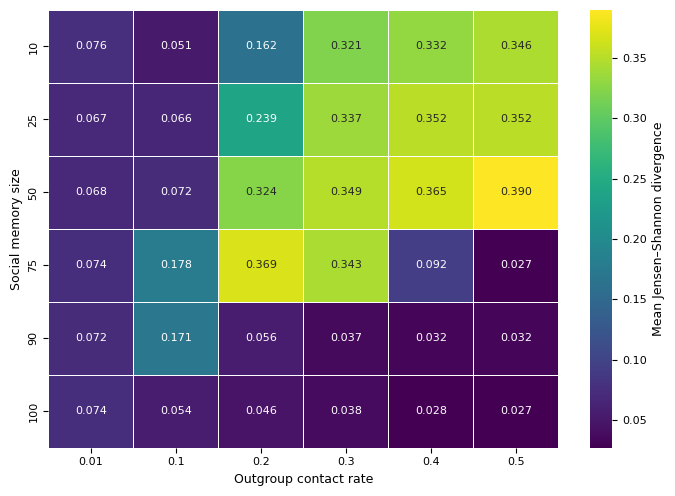

In [31]:
# Load aggregated full-sweep results
df = pd.read_csv(AGGREGATED_DIR / "full_sweep_means.csv")

# Maximum JS divergence used for consistent colour scaling
global_vmax = df["mean_js_final_mean"].max()

# Variable to plot
column = "mean_js_final_mean"

# Create heatmap data
heatmap_data = df.pivot(
    index="social_memory_size",
    columns="p_outgroup",
    values=column,
)

# Plot
plt.figure(figsize=(7, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    linewidths=0.5,
    vmax=global_vmax,
    cbar_kws={"label": "Mean Jensen–Shannon divergence"},
)

plt.xlabel("Outgroup contact rate")
plt.ylabel("Social memory size")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "heatmap_js_divergence.pdf",
    bbox_inches="tight",
)

plt.show()
plt.close()

### 1B. Heatmap: Risk perception

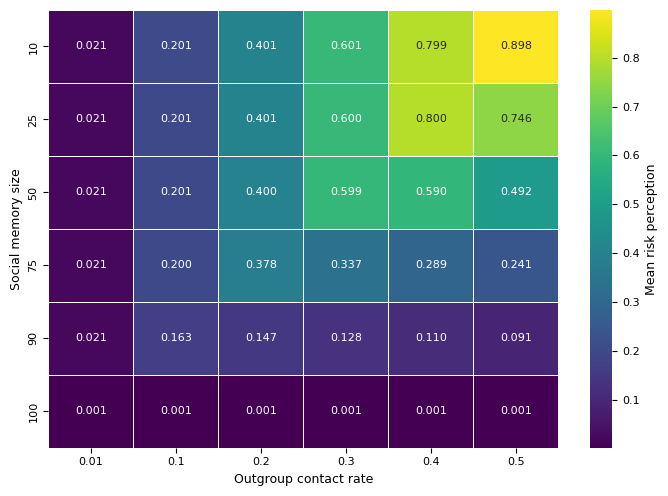

In [32]:
# Variable to plot
column = "mean_risk_perception_final_mean"

# Create heatmap data
heatmap_data = df.pivot(
    index="social_memory_size",
    columns="p_outgroup",
    values=column,
)

# Plot
plt.figure(figsize=(7, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Mean risk perception"},
)

plt.xlabel("Outgroup contact rate")
plt.ylabel("Social memory size")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "heatmap_risk_perception.pdf",
    bbox_inches="tight",
)

plt.show()
plt.close()

### Figure 1: Combined Heatmaps

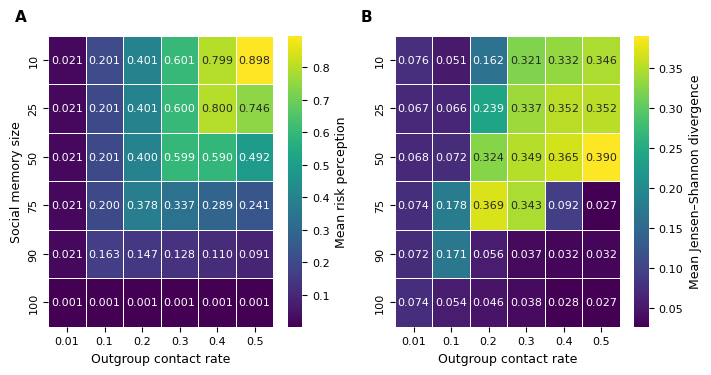

In [33]:
# Publication figure settings
plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.2, 3.8),
)

# Panel A: risk perception
sns.heatmap(
    df.pivot(
        index="social_memory_size",
        columns="p_outgroup",
        values="mean_risk_perception_final_mean",
    ),
    ax=axes[0],
    annot=True,
    fmt=".3f",
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Mean risk perception"},
)

axes[0].set_xlabel("Outgroup contact rate")
axes[0].set_ylabel("Social memory size")
axes[0].text(
    -0.15,
    1.05,
    "A",
    transform=axes[0].transAxes,
    fontsize=11,
    fontweight="bold",
)

# Panel B: JS divergence
sns.heatmap(
    df.pivot(
        index="social_memory_size",
        columns="p_outgroup",
        values="mean_js_final_mean",
    ),
    ax=axes[1],
    annot=True,
    fmt=".3f",
    cmap="viridis",
    linewidths=0.5,
    vmax=global_vmax,
    cbar_kws={"label": "Mean Jensen–Shannon divergence"},
)

axes[1].set_xlabel("Outgroup contact rate")
axes[1].set_ylabel("")
axes[1].text(
    -0.15,
    1.05,
    "B",
    transform=axes[1].transAxes,
    fontsize=11,
    fontweight="bold",
)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "figure_1_heatmaps.pdf",
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

### Figure 2: Risk perception and inference

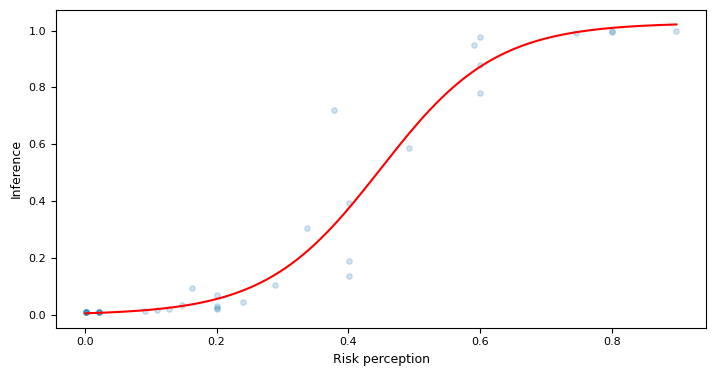

In [34]:
df = pd.read_csv(FULL_SWEEP)

df = df.rename(
    columns={
        "mean_risk_perception_final_mean": "risk_perception",
        "mean_inference_final_mean": "inference",
    }
)


def logistic(x, L, k, x0):
    """Logistic function used to fit inference as a function of risk perception."""
    return L / (1 + np.exp(-k * (x - x0)))


x = df["risk_perception"].to_numpy()
y = df["inference"].to_numpy()

# Initial parameter estimates
initial_parameters = [
    1,
    5,
    np.median(x),
]

parameters, _ = curve_fit(
    logistic,
    x,
    y,
    p0=initial_parameters,
    maxfev=10000,
)

L, k, x0 = parameters

x_fit = np.linspace(
    x.min(),
    x.max(),
    200,
)

y_fit = logistic(
    x_fit,
    L,
    k,
    x0,
)

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

ax.scatter(
    x,
    y,
    alpha=0.2,
    s=15,
)

ax.plot(
    x_fit,
    y_fit,
    color="red",
)

ax.set_xlabel(
    "Risk perception",
    fontsize=AXIS_LABEL_SIZE,
)

ax.set_ylabel(
    "Inference",
    fontsize=AXIS_LABEL_SIZE,
)

ax.tick_params(
    axis="both",
    labelsize=TICK_LABEL_SIZE,
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "figure_2_risk_inference.pdf",
    bbox_inches="tight",
)

plt.show()
plt.close()

### Figure 3: Inference and JS divergence

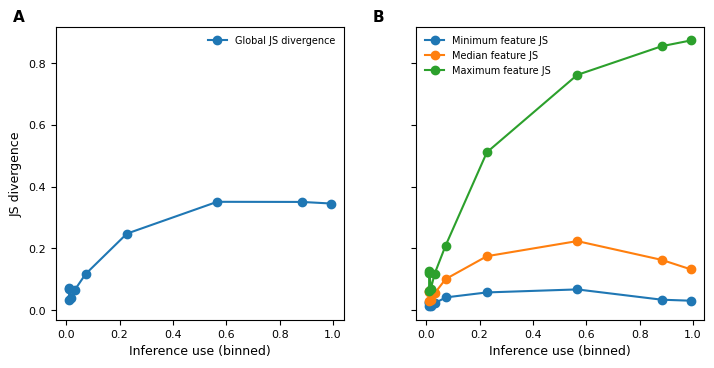

In [35]:
df = pd.read_csv(FULL_SWEEP)

df["inference_bin"] = pd.qcut(
    df["mean_inference_final_mean"],
    10,
    duplicates="drop",
)

agg_global = (
    df.groupby("inference_bin", observed=True)
      .agg(
          global_js=("mean_js_final_mean", "mean"),
      )
)

agg_feature = (
    df.groupby("inference_bin", observed=True)
      .agg(
          min_js=("mean_min_js_final_mean", "mean"),
          median_js=("mean_median_js_final_mean", "mean"),
          max_js=("mean_max_js_final_mean", "mean"),
      )
)

x = [interval.mid for interval in agg_global.index]


# Create figure
fig, axes = plt.subplots(
    1,
    2,
    figsize=FIGURE_SIZE,
    sharex=True,
    sharey=True,
)


# Panel A: Global JS divergence
axes[0].plot(
    x,
    agg_global["global_js"],
    marker="o",
    label="Global JS divergence",
)

axes[0].set_xlabel(
    "Inference use (binned)",
    fontsize=AXIS_LABEL_SIZE,
)

axes[0].set_ylabel(
    "JS divergence",
    fontsize=AXIS_LABEL_SIZE,
)

axes[0].tick_params(
    axis="both",
    labelsize=TICK_LABEL_SIZE,
)

axes[0].legend(
    fontsize=LEGEND_SIZE,
    frameon=False,
    loc="best",
)

axes[0].text(
    -0.15,
    1.06,
    "A",
    transform=axes[0].transAxes,
    fontsize=PANEL_LABEL_SIZE,
    fontweight="bold",
    va="top",
)


# Panel B: Feature-level JS divergence
axes[1].plot(
    x,
    agg_feature["min_js"],
    marker="o",
    label="Minimum feature JS",
)

axes[1].plot(
    x,
    agg_feature["median_js"],
    marker="o",
    label="Median feature JS",
)

axes[1].plot(
    x,
    agg_feature["max_js"],
    marker="o",
    label="Maximum feature JS",
)

axes[1].set_xlabel(
    "Inference use (binned)",
    fontsize=AXIS_LABEL_SIZE,
)

axes[1].set_ylabel("")

axes[1].tick_params(
    axis="both",
    labelsize=TICK_LABEL_SIZE,
)

axes[1].legend(
    fontsize=LEGEND_SIZE,
    frameon=False,
    loc="best",
)

axes[1].text(
    -0.15,
    1.06,
    "B",
    transform=axes[1].transAxes,
    fontsize=PANEL_LABEL_SIZE,
    fontweight="bold",
    va="top",
)


# Final layout
plt.subplots_adjust(
    wspace=0.25,
    left=0.08,
    right=0.98,
    bottom=0.16,
    top=0.93,
)

plt.savefig(
    FIGURES_DIR / "figure_3_js_divergence.pdf",
    bbox_inches="tight",
)

plt.show()
plt.close()

## B. Counterfactual variants

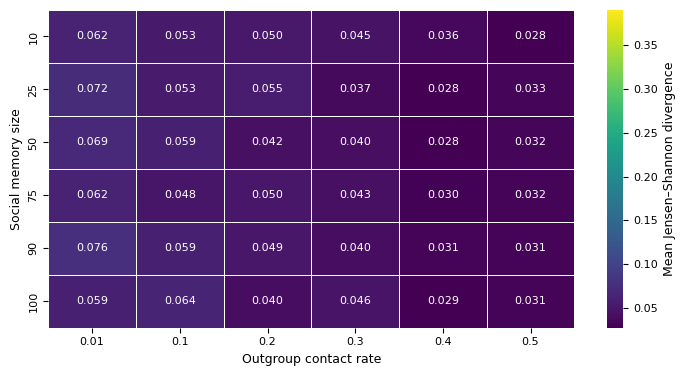

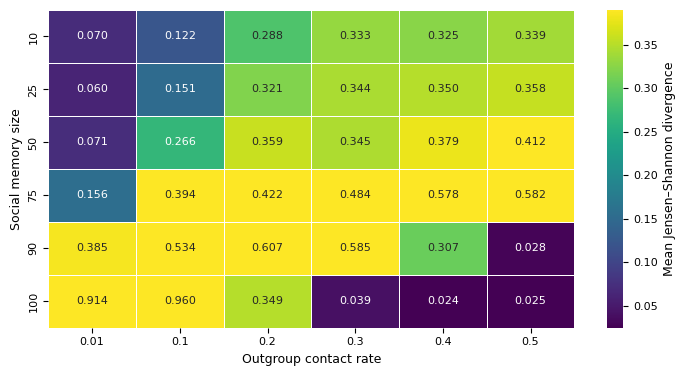

In [36]:
df = pd.read_csv(MODEL_VARIANTS)

column = "mean_js_final_mean"

variant_titles = {
    0: "No inference",
    2: "Always inference",
}

# Use the full-sweep maximum to compare on the same scale
full_sweep = pd.read_csv(FULL_SWEEP)
global_vmax = full_sweep[column].max()

for variant in sorted(df["model_variant"].unique()):

    df_sub = df[df["model_variant"] == variant]

    pivot = df_sub.pivot(
        index="social_memory_size",
        columns="p_outgroup",
        values=column,
    )

    title = variant_titles.get(
        variant,
        f"Variant {variant}",
    )

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    sns.heatmap(
        pivot,
        ax=ax,
        annot=True,
        fmt=".3f",
        cmap="viridis",
        linewidths=0.5,
        vmax=global_vmax,
        cbar_kws={
            "label": "Mean Jensen–Shannon divergence",
        },
    )

    ax.set_xlabel(
        "Outgroup contact rate",
        fontsize=AXIS_LABEL_SIZE,
    )

    ax.set_ylabel(
        "Social memory size",
        fontsize=AXIS_LABEL_SIZE,
    )

    ax.tick_params(
        axis="both",
        labelsize=TICK_LABEL_SIZE,
    )

    plt.tight_layout()


    filename = {
        0: "no_inference",
        2: "always_inference",
    }.get(
        variant,
        f"variant_{variant}",
    )

    plt.savefig(
        FIGURES_DIR / f"heatmap_js_divergence_{filename}.pdf",
        bbox_inches="tight",
    )

    plt.show()
    plt.close()

### Figure 4: Counterfactual model variants combined

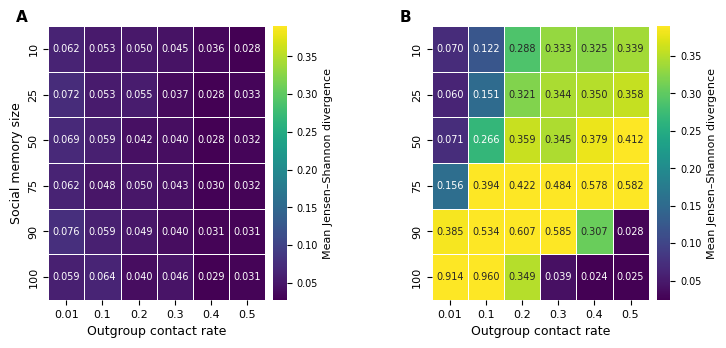

In [37]:
df = pd.read_csv(MODEL_VARIANTS)

column = "mean_js_final_mean"

variant_titles = {
    0: "No inference",
    2: "Always inference",
}

full_sweep = pd.read_csv(FULL_SWEEP)
global_vmax = full_sweep[column].max()


fig, axes = plt.subplots(
    1,
    2,
    figsize=FIGURE_SIZE,
)


for ax, variant, panel_label in zip(
    axes,
    [0, 2],
    ["A", "B"],
):

    df_sub = df[df["model_variant"] == variant]

    pivot = df_sub.pivot(
        index="social_memory_size",
        columns="p_outgroup",
        values=column,
    )

    sns.heatmap(
        pivot,
        ax=ax,
        annot=True,
        fmt=".3f",
        cmap="viridis",
        linewidths=0.5,
        vmax=global_vmax,
        annot_kws={"size": ANNOTATION_SIZE},
        cbar_kws={
            "label": "Mean Jensen–Shannon divergence",
            "pad": 0.03,
        },
    )

    ax.set_xlabel(
        "Outgroup contact rate",
        fontsize=AXIS_LABEL_SIZE,
    )

    if variant == 0:
        ax.set_ylabel(
            "Social memory size",
            fontsize=AXIS_LABEL_SIZE,
        )
    else:
        ax.set_ylabel("")

    ax.tick_params(
        axis="both",
        labelsize=TICK_LABEL_SIZE,
    )

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(
        labelsize=COLORBAR_TICK_SIZE,
    )

    cbar.set_label(
        "Mean Jensen–Shannon divergence",
        fontsize=COLORBAR_LABEL_SIZE,
    )

    ax.text(
        -0.15,
        1.06,
        panel_label,
        transform=ax.transAxes,
        fontsize=PANEL_LABEL_SIZE,
        fontweight="bold",
        va="top",
    )


plt.subplots_adjust(
    wspace=0.45,
    left=0.08,
    right=0.98,
    bottom=0.16,
    top=0.88,
)

plt.savefig(
    FIGURES_DIR / "figure_4_heatmap_variants.pdf",
    bbox_inches="tight",
)

plt.show()
plt.close()

## C. Time series

In [38]:
time_series_inputs = {
    "high": TIME_SERIES_HIGH,
    "low": TIME_SERIES_LOW,
}

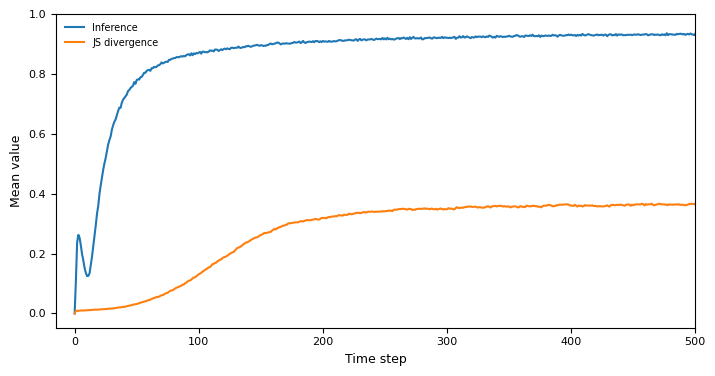

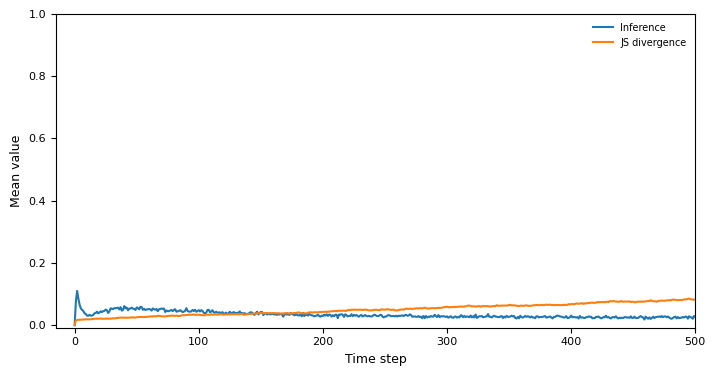

In [39]:
for name, input_file in time_series_inputs.items():

    df = pd.read_csv(input_file)

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    ax.plot(
        df["step"],
        df["proportion_inference_mean"],
        label="Inference",
    )

    ax.plot(
        df["step"],
        df["between_group_js_mean"],
        label="JS divergence",
    )

    ax.set_xlim(-15, 500)
    ax.set_ylim(top=1)

    ax.set_xlabel(
        "Time step",
        fontsize=AXIS_LABEL_SIZE,
    )

    ax.set_ylabel(
        "Mean value",
        fontsize=AXIS_LABEL_SIZE,
    )

    ax.tick_params(
        axis="both",
        labelsize=TICK_LABEL_SIZE,
    )

    ax.legend(
        fontsize=LEGEND_SIZE,
        frameon=False,
    )

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / f"time_series_dynamics_{name}.pdf",
        bbox_inches="tight",
    )

    plt.show()
    plt.close()

### Figure 5: Time-series dynamics

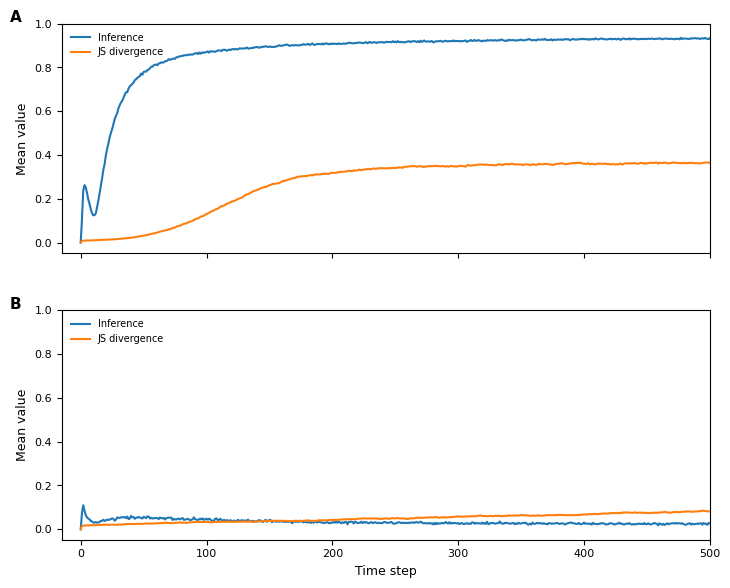

In [40]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(7.2, 6.0),
    sharex=True,
    sharey=True,
)


for ax, (name, input_file), panel_label in zip(
    axes,
    time_series_inputs.items(),
    ["A", "B"],
):

    df = pd.read_csv(input_file)

    ax.plot(
        df["step"],
        df["proportion_inference_mean"],
        label="Inference",
    )

    ax.plot(
        df["step"],
        df["between_group_js_mean"],
        label="JS divergence",
    )

    ax.set_xlim(-15, 500)
    ax.set_ylim(top=1)

    ax.set_ylabel(
        "Mean value",
        fontsize=AXIS_LABEL_SIZE,
    )

    ax.tick_params(
        axis="both",
        labelsize=TICK_LABEL_SIZE,
    )

    ax.legend(
        fontsize=LEGEND_SIZE,
        frameon=False,
        loc="upper left",
    )

    ax.text(
        -0.08,
        1.06,
        panel_label,
        transform=ax.transAxes,
        fontsize=PANEL_LABEL_SIZE,
        fontweight="bold",
        va="top",
    )


axes[1].set_xlabel(
    "Time step",
    fontsize=AXIS_LABEL_SIZE,
)


plt.subplots_adjust(
    hspace=0.25,
    left=0.08,
    right=0.98,
    bottom=0.10,
    top=0.96,
)

plt.savefig(
    FIGURES_DIR / "figure_5_time_series.pdf",
    bbox_inches="tight",
)

plt.show()
plt.close()